# French to English Translation Project

This notebook implements various recurrent neural network (RNN) architectures for French to English translation, including RNN, LSTM, GRU, and Seq2Seq models. The project utilizes the Tatoeba fra-eng dataset (`fra.txt`).

## SECTION 1 - Setup

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import nltk
from nltk.tokenize import word_tokenize
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from collections import Counter
import string
import re
import random

nltk.download('punkt')

# Set device (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Fix seed to 42 for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Using device: cpu


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [10]:
# Download punkt_tab as suggested by the error message
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

### Upload Dataset

Please upload the `fra.txt` file manually when prompted. This file contains French-English sentence pairs.

In [6]:
# Upload fra.txt using: from google.colab import files; files.upload()
from google.colab import files

print("Please upload the 'fra.txt' file.")
uploaded = files.upload()

# Ensure the uploaded file is fra.txt
if 'fra.txt' in uploaded:
    file_name = 'fra.txt'
    print(f"Uploaded file: {file_name}")
else:
    print("Warning: 'fra.txt' was not found among the uploaded files. Please ensure you upload the correct dataset.")
    # If fra.txt is not uploaded, try to use the first uploaded file, but this might lead to further errors
    if uploaded:
        file_name = list(uploaded.keys())[0]
        print(f"Proceeding with first uploaded file: {file_name}")
    else:
        raise FileNotFoundError("No file was uploaded or 'fra.txt' was not found. Please upload 'fra.txt'.")

Please upload the 'fra.txt' file.


Saving fra.txt to fra (1).txt
Proceeding with first uploaded file: fra (1).txt


In [7]:
# Read the file, keep only first 15000 pairs (tab separated: English, French)
data = pd.read_csv(file_name, sep='\t', header=None, names=['english', 'french', 'attribution'])
data = data.iloc[:15000, :2] # Keep only the first 15000 pairs and relevant columns

print(f"Original dataset shape: {data.shape}")
print("First 5 rows of the raw data:")
display(data.head())

# Clean sentences: lowercase, remove punctuation except apostrophes
def clean_sentence(sentence):
    # Convert to lowercase
    sentence = sentence.lower()
    # Remove punctuation except apostrophes
    sentence = re.sub(f'[{re.escape(string.punctuation.replace("\'", ""))}]', '', sentence)
    # Remove multiple spaces
    sentence = re.sub('\s+', ' ', sentence).strip()
    return sentence

data['english'] = data['english'].apply(clean_sentence)
data['french'] = data['french'].apply(clean_sentence)

print("\nFirst 5 rows after cleaning:")
display(data.head())
print(f"Number of sentence pairs after cleaning: {len(data)}")

<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_9594/1833311078.py:16: SyntaxWarning: invalid escape sequence '\s'
  sentence = re.sub('\s+', ' ', sentence).strip()


Original dataset shape: (15000, 2)
First 5 rows of the raw data:


,english,french
0,Go.,Va !
1,Go.,Marche.
2,Go.,En route !
3,Go.,Bouge !
4,Hi.,Salut !



First 5 rows after cleaning:


,english,french
0,go,va
1,go,marche
2,go,en route
3,go,bouge
4,hi,salut


Number of sentence pairs after cleaning: 15000


## SECTION 2 - Data Preparation

In [11]:
# Define special tokens and their indices
PAD_IDX = 0
BOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

SPECIAL_TOKENS = ['<pad>', '<bos>', '<eos>', '<unk>']

# Tokenization function
def tokenize_sentence(sentence):
    return [token for token in word_tokenize(sentence)]

# Build vocabulary class
class Vocabulary:
    def __init__(self, min_freq):
        self.stoi = {}
        self.itos = {}
        self.min_freq = min_freq
        self.uniq_tokens = 0

        # Add special tokens initially
        for i, token in enumerate(SPECIAL_TOKENS):
            self.stoi[token] = i
            self.itos[i] = token
            self.uniq_tokens += 1

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        for sentence in sentence_list:
            for word in tokenize_sentence(sentence):
                frequencies[word] += 1

        for word, freq in frequencies.items():
            if freq >= self.min_freq:
                self.stoi[word] = self.uniq_tokens
                self.itos[self.uniq_tokens] = word
                self.uniq_tokens += 1

    def numericalize(self, sentence):
        tokenized_sentence = tokenize_sentence(sentence)
        return [self.stoi.get(token, UNK_IDX) for token in tokenized_sentence]

    def __len__(self):
        return self.uniq_tokens

# Build vocabularies for English and French
min_freq = 2

english_vocab = Vocabulary(min_freq)
english_vocab.build_vocabulary(data['english'].tolist())

french_vocab = Vocabulary(min_freq)
french_vocab.build_vocabulary(data['french'].tolist())

print(f"English vocabulary size: {len(english_vocab)}")
print(f"French vocabulary size: {len(french_vocab)}")

English vocabulary size: 1864
French vocabulary size: 2978


In [12]:
# Encode all sentences: add <bos> and <eos>, pad or truncate to max_len=20
MAX_LEN = 20

def encode_and_pad(sentence, vocab, max_len):
    numericalized = [BOS_IDX] + vocab.numericalize(sentence) + [EOS_IDX]

    if len(numericalized) > max_len:
        numericalized = numericalized[:max_len - 1] + [EOS_IDX] # Ensure EOS is present if truncated
    elif len(numericalized) < max_len:
        numericalized += [PAD_IDX] * (max_len - len(numericalized))

    return numericalized

data['english_encoded'] = data['english'].apply(lambda x: encode_and_pad(x, english_vocab, MAX_LEN))
data['french_encoded'] = data['french'].apply(lambda x: encode_and_pad(x, french_vocab, MAX_LEN))

print("5 example encoded pairs:")
for i in range(5):
    eng_sent = data['english'].iloc[i]
    eng_enc = data['english_encoded'].iloc[i]
    fr_sent = data['french'].iloc[i]
    fr_enc = data['french_encoded'].iloc[i]

    print(f"English: '{eng_sent}' -> {eng_enc}")
    print(f"French:  '{fr_sent}' -> {fr_enc}")
    print("-" * 30)


# Create a custom dataset
class TranslationDataset(Dataset):
    def __init__(self, english_sentences, french_sentences):
        self.english_sentences = english_sentences
        self.french_sentences = french_sentences

    def __len__(self):
        return len(self.english_sentences)

    def __getitem__(self, idx):
        return {
            'english': torch.tensor(self.english_sentences[idx], dtype=torch.long),
            'french': torch.tensor(self.french_sentences[idx], dtype=torch.long)
        }

# Split 80% train / 10% val / 10% test
train_df, test_df = train_test_split(data, test_size=0.2, random_state=SEED)
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=SEED)

# Reset indices for clean dataset creation
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

# Create Dataset objects
train_dataset = TranslationDataset(train_df['english_encoded'].tolist(), train_df['french_encoded'].tolist())
val_dataset = TranslationDataset(val_df['english_encoded'].tolist(), val_df['french_encoded'].tolist())
test_dataset = TranslationDataset(test_df['english_encoded'].tolist(), test_df['french_encoded'].tolist())

# Create DataLoaders with batch_size=32
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in val_loader: {len(val_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

5 example encoded pairs:
English: 'go' -> [1, 4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
French:  'va' -> [1, 4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
------------------------------
English: 'go' -> [1, 4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
French:  'marche' -> [1, 5, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
------------------------------
English: 'go' -> [1, 4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
French:  'en route' -> [1, 6, 7, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
------------------------------
English: 'go' -> [1, 4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
French:  'bouge' -> [1, 8, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
------------------------------
English: 'hi' -> [1, 5, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
French:  'salut' -> [1, 9, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
------------------------------
Train set size: 12000
Va

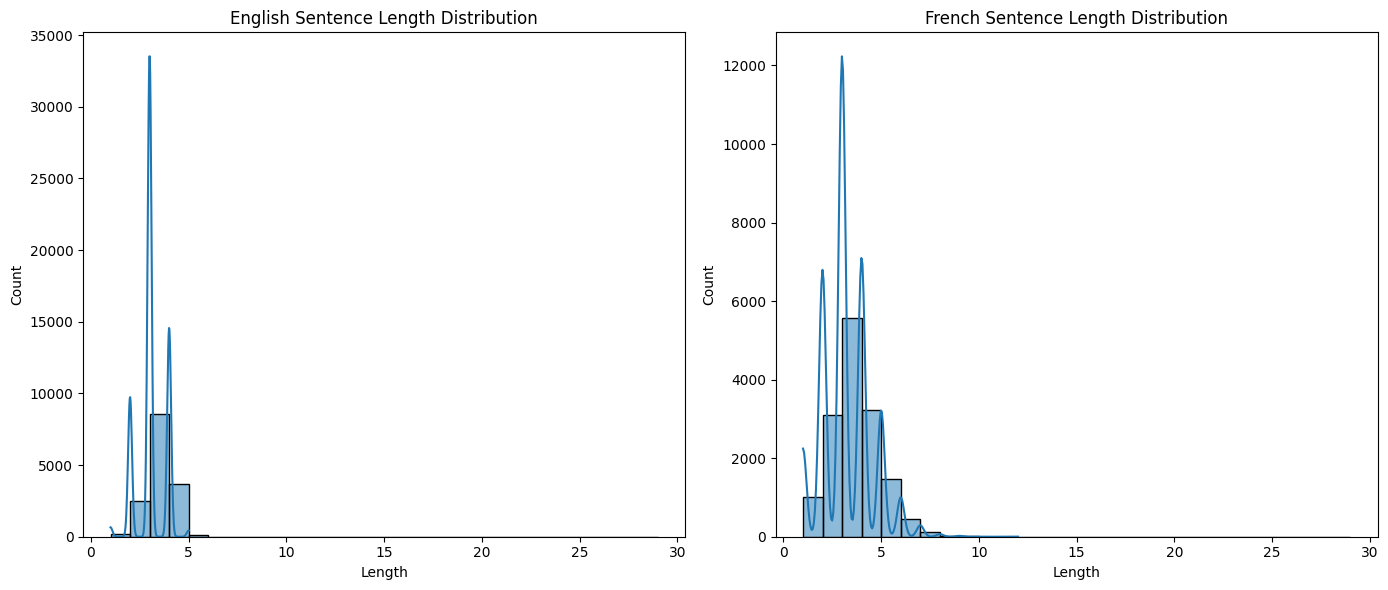

In [13]:
# Plot sentence length distribution for both languages
english_lengths = [len(tokenize_sentence(s)) for s in data['english']]
french_lengths = [len(tokenize_sentence(s)) for s in data['french']]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(english_lengths, bins=range(1, 30), kde=True)
plt.title('English Sentence Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(french_lengths, bins=range(1, 30), kde=True)
plt.title('French Sentence Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## SECTION 3 - Simple RNN Language Model

In [17]:
# Simple RNN language model
class RNNDecoder(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, n_layers, dropout_rate, pad_idx):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(input_dim, embedding_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, n_layers, dropout=dropout_rate, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, input_seq, hidden_state):
        # input_seq: [batch_size, seq_len]
        # hidden_state: [n_layers, batch_size, hidden_dim]

        embedded = self.dropout(self.embedding(input_seq))
        # embedded: [batch_size, seq_len, embedding_dim]

        output, hidden = self.rnn(embedded, hidden_state)
        # output: [batch_size, seq_len, hidden_dim]
        # hidden: [n_layers, batch_size, hidden_dim]

        prediction = self.fc_out(output)
        # prediction: [batch_size, seq_len, output_dim]

        return prediction, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(self.n_layers, batch_size, self.hidden_dim).to(device)

# Model parameters for Language Models (RNN, LSTM, GRU)
LM_INPUT_DIM = len(english_vocab) # English vocabulary size for predicting next English word
LM_OUTPUT_DIM = len(english_vocab) # Predict next English word
LM_EMBEDDING_DIM = 256
LM_HIDDEN_DIM = 128
LM_N_LAYERS = 1
LM_DROPOUT_RATE = 0.0 # No dropout for simple RNN, LSTM, GRU language models

rnn_model = RNNDecoder(LM_INPUT_DIM, LM_EMBEDDING_DIM, LM_HIDDEN_DIM, LM_OUTPUT_DIM, LM_N_LAYERS, LM_DROPOUT_RATE, PAD_IDX).to(device)
rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

print("\nSimple RNN Model Summary:")
print(rnn_model)
print(f"The simple RNN model has {sum(p.numel() for p in rnn_model.parameters() if p.requires_grad):,} trainable parameters")

def train_language_model(model, iterator, optimizer, criterion, clip_val):
    model.train()
    epoch_loss = 0
    all_grad_norms = []

    for i, batch in enumerate(iterator):
        src = batch['english'].to(device) # For LM, we're predicting next token in English

        # src: [batch_size, seq_len]
        # target: [batch_size, seq_len]
        # input to decoder will be src[:, :-1]
        # target for loss will be src[:, 1:]

        optimizer.zero_grad()

        batch_size = src.shape[0]
        input_seq = src[:, :-1] # all but last token as input
        target = src[:, 1:] # all but first token as target

        hidden = model.init_hidden(batch_size)

        output, _ = model(input_seq, hidden)
        # output: [batch_size, seq_len-1, output_dim]
        # hidden: [n_layers, batch_size, hidden_dim]

        output_dim = output.shape[-1]
        output = output.reshape(-1, output_dim) # [batch_size * (seq_len-1), output_dim]
        target = target.reshape(-1) # [batch_size * (seq_len-1)]

        loss = criterion(output, target)
        loss.backward()

        # Gradient clipping
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), clip_val)
        all_grad_norms.append(grad_norm.item())

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator), all_grad_norms

def evaluate_language_model(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for batch in iterator:
            src = batch['english'].to(device)

            batch_size = src.shape[0]
            input_seq = src[:, :-1]
            target = src[:, 1:]

            hidden = model.init_hidden(batch_size)

            output, _ = model(input_seq, hidden)
            output_dim = output.shape[-1]
            output = output.reshape(-1, output_dim)
            target = target.reshape(-1)

            loss = criterion(output, target)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

# Training loop for Simple RNN
N_EPOCHS = 10
CLIP = 1.0

rnn_train_losses = []
rnn_val_losses = []
rnn_train_perplexities = []
rnn_val_perplexities = []

rnn_grad_norms_per_epoch = [] # Store list of grad norms for each epoch

print("\nTraining Simple RNN Language Model...")
for epoch in range(N_EPOCHS):
    train_loss, grad_norms = train_language_model(rnn_model, train_loader, rnn_optimizer, criterion, CLIP)
    val_loss = evaluate_language_model(rnn_model, val_loader, criterion)

    rnn_train_losses.append(train_loss)
    rnn_val_losses.append(val_loss)

    rnn_train_perplexities.append(np.exp(train_loss))
    rnn_val_perplexities.append(np.exp(val_loss))

    # Store grad norms for analysis (e.g., first 3 epochs)
    if epoch < 3:
        rnn_grad_norms_per_epoch.append({'epoch': epoch+1, 'grad_norms': grad_norms})

    print(f'Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Train PPL: {np.exp(train_loss):.2f} | Val Loss: {val_loss:.3f} | Val PPL: {np.exp(val_loss):.2f}')

print("\nSimple RNN Language Model Training Complete.")


Simple RNN Model Summary:
RNNDecoder(
  (embedding): Embedding(1864, 256, padding_idx=0)
  (rnn): RNN(256, 128, batch_first=True)
  (fc_out): Linear(in_features=128, out_features=1864, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
)
The simple RNN model has 767,048 trainable parameters

Training Simple RNN Language Model...
Epoch: 01 | Train Loss: 3.870 | Train PPL: 47.93 | Val Loss: 3.357 | Val PPL: 28.71
Epoch: 02 | Train Loss: 3.152 | Train PPL: 23.38 | Val Loss: 3.129 | Val PPL: 22.86
Epoch: 03 | Train Loss: 2.926 | Train PPL: 18.66 | Val Loss: 3.013 | Val PPL: 20.35
Epoch: 04 | Train Loss: 2.790 | Train PPL: 16.28 | Val Loss: 2.942 | Val PPL: 18.95
Epoch: 05 | Train Loss: 2.694 | Train PPL: 14.79 | Val Loss: 2.899 | Val PPL: 18.15
Epoch: 06 | Train Loss: 2.622 | Train PPL: 13.76 | Val Loss: 2.868 | Val PPL: 17.60
Epoch: 07 | Train Loss: 2.569 | Train PPL: 13.05 | Val Loss: 2.840 | Val PPL: 17.11
Epoch: 08 | Train Loss: 2.525 | Train PPL: 12.49 | Val Loss: 2.834 | Val PPL:

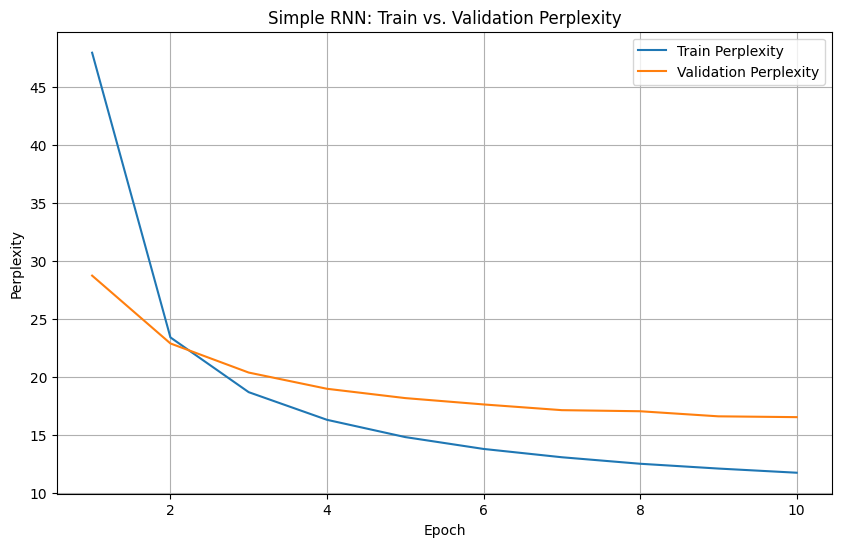

In [19]:
# Consolidated plotting functions will be generated later.

In [ ]:
# Consolidated plotting functions will be generated later.

### Simple RNN Model Summary

```
RNNDecoder(
  (embedding): Embedding(1864, 256, padding_idx=0)
  (rnn): RNN(256, 128, batch_first=True)
  (fc_out): Linear(in_features=128, out_features=1864, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
)
The simple RNN model has 767,048 trainable parameters
```

## SECTION 4 - LSTM Language Model

In [18]:
# LSTM Decoder Model
class LSTMDecoder(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, n_layers, dropout_rate, pad_idx):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(input_dim, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers, dropout=dropout_rate, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, input_seq, hidden_state, cell_state):
        # input_seq: [batch_size, seq_len]
        # hidden_state: [n_layers, batch_size, hidden_dim]
        # cell_state: [n_layers, batch_size, hidden_dim]

        embedded = self.dropout(self.embedding(input_seq))
        # embedded: [batch_size, seq_len, embedding_dim]

        output, (hidden, cell) = self.lstm(embedded, (hidden_state, cell_state))
        # output: [batch_size, seq_len, hidden_dim]
        # hidden: [n_layers, batch_size, hidden_dim]
        # cell: [n_layers, batch_size, hidden_dim]

        prediction = self.fc_out(output)
        # prediction: [batch_size, seq_len, output_dim]

        return prediction, hidden, cell

    def init_hidden_cell(self, batch_size):
        hidden = torch.zeros(self.n_layers, batch_size, self.hidden_dim).to(device)
        cell = torch.zeros(self.n_layers, batch_size, self.hidden_dim).to(device)
        return hidden, cell

lstm_model = LSTMDecoder(LM_INPUT_DIM, LM_EMBEDDING_DIM, LM_HIDDEN_DIM, LM_OUTPUT_DIM, LM_N_LAYERS, LM_DROPOUT_RATE, PAD_IDX).to(device)
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)
# Criterion is the same as for RNN

print("\nLSTM Model Summary:")
print(lstm_model)
print(f"The LSTM model has {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,} trainable parameters")

def train_lstm_language_model(model, iterator, optimizer, criterion, clip_val):
    model.train()
    epoch_loss = 0
    all_grad_norms = []

    for i, batch in enumerate(iterator):
        src = batch['english'].to(device)

        optimizer.zero_grad()

        batch_size = src.shape[0]
        input_seq = src[:, :-1]
        target = src[:, 1:]

        hidden, cell = model.init_hidden_cell(batch_size)

        output, _, _ = model(input_seq, hidden, cell)

        output_dim = output.shape[-1]
        output = output.reshape(-1, output_dim)
        target = target.reshape(-1)

        loss = criterion(output, target)
        loss.backward()

        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), clip_val)
        all_grad_norms.append(grad_norm.item())

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator), all_grad_norms

def evaluate_lstm_language_model(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for batch in iterator:
            src = batch['english'].to(device)

            batch_size = src.shape[0]
            input_seq = src[:, :-1]
            target = src[:, 1:]

            hidden, cell = model.init_hidden_cell(batch_size)

            output, _, _ = model(input_seq, hidden, cell)
            output_dim = output.shape[-1]
            output = output.reshape(-1, output_dim)
            target = target.reshape(-1)

            loss = criterion(output, target)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

# Training loop for LSTM
N_EPOCHS_LSTM = 10
CLIP_LSTM = 1.0

lstm_train_losses = []
lstm_val_losses = []
lstm_train_perplexities = []
lstm_val_perplexities = []

lstm_grad_norms_per_epoch = []

print("\nTraining LSTM Language Model...")
for epoch in range(N_EPOCHS_LSTM):
    train_loss, grad_norms = train_lstm_language_model(lstm_model, train_loader, lstm_optimizer, criterion, CLIP_LSTM)
    val_loss = evaluate_lstm_language_model(lstm_model, val_loader, criterion)

    lstm_train_losses.append(train_loss)
    lstm_val_losses.append(val_loss)

    lstm_train_perplexities.append(np.exp(train_loss))
    lstm_val_perplexities.append(np.exp(val_loss))

    if epoch < 3:
        lstm_grad_norms_per_epoch.append({'epoch': epoch+1, 'grad_norms': grad_norms})

    print(f'Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Train PPL: {np.exp(train_loss):.2f} | Val Loss: {val_loss:.3f} | Val PPL: {np.exp(val_loss):.2f}')

print("\nLSTM Language Model Training Complete.")


LSTM Model Summary:
LSTMDecoder(
  (embedding): Embedding(1864, 256, padding_idx=0)
  (lstm): LSTM(256, 128, batch_first=True)
  (fc_out): Linear(in_features=128, out_features=1864, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
)
The LSTM model has 915,272 trainable parameters

Training LSTM Language Model...
Epoch: 01 | Train Loss: 3.982 | Train PPL: 53.65 | Val Loss: 3.467 | Val PPL: 32.03
Epoch: 02 | Train Loss: 3.251 | Train PPL: 25.82 | Val Loss: 3.207 | Val PPL: 24.69
Epoch: 03 | Train Loss: 2.999 | Train PPL: 20.07 | Val Loss: 3.066 | Val PPL: 21.46
Epoch: 04 | Train Loss: 2.833 | Train PPL: 16.99 | Val Loss: 2.969 | Val PPL: 19.47
Epoch: 05 | Train Loss: 2.714 | Train PPL: 15.10 | Val Loss: 2.908 | Val PPL: 18.31
Epoch: 06 | Train Loss: 2.628 | Train PPL: 13.84 | Val Loss: 2.864 | Val PPL: 17.53
Epoch: 07 | Train Loss: 2.562 | Train PPL: 12.96 | Val Loss: 2.837 | Val PPL: 17.06
Epoch: 08 | Train Loss: 2.508 | Train PPL: 12.29 | Val Loss: 2.817 | Val PPL: 16.73
Epoch: 0

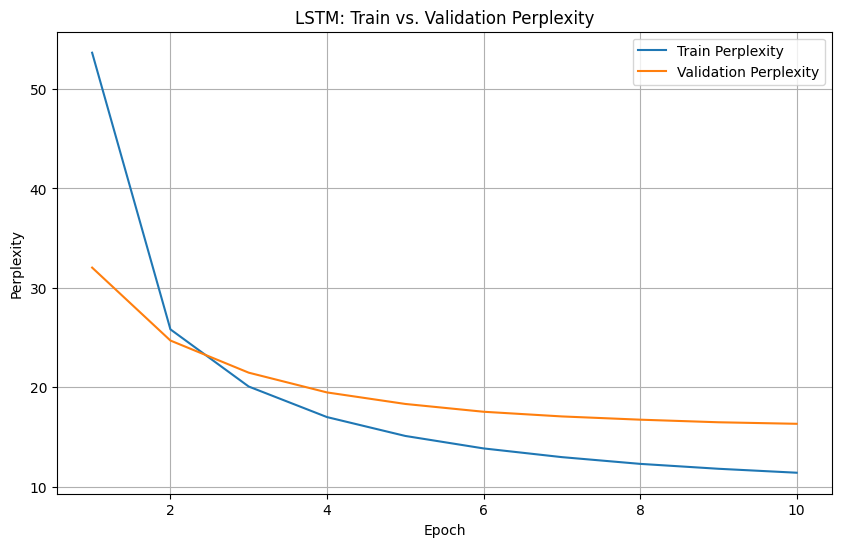

In [20]:
# Consolidated plotting functions will be generated later.

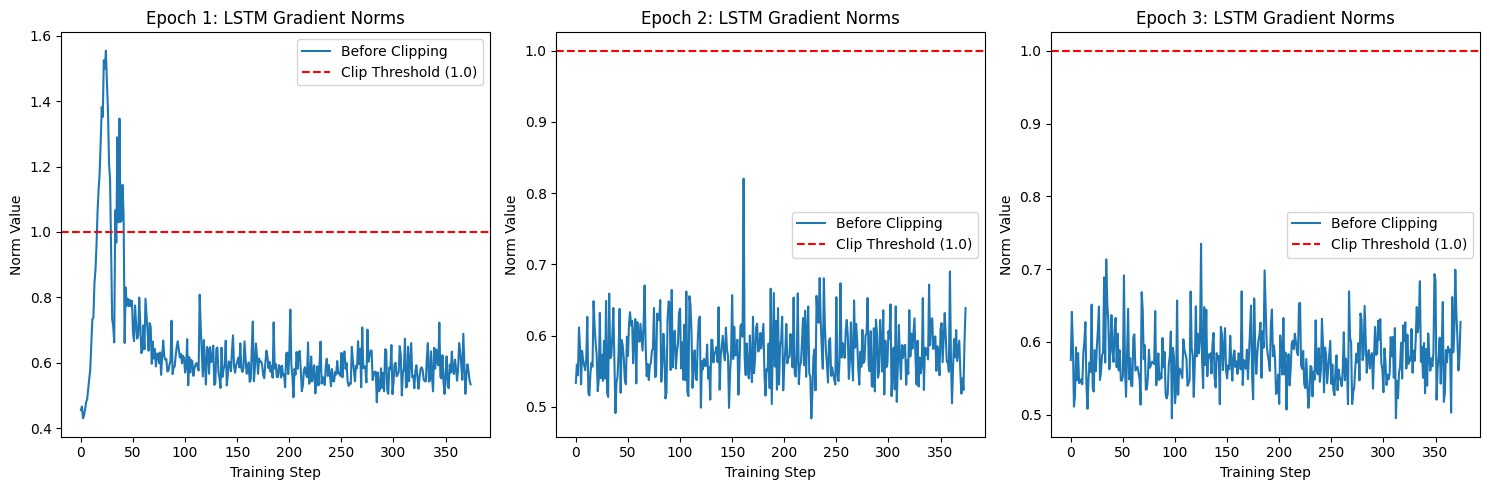

In [21]:
# Consolidated plotting functions will be generated later.

## SECTION 5 - GRU Language Model

In [22]:
# GRU Decoder Model
class GRUDecoder(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, n_layers, dropout_rate, pad_idx):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(input_dim, embedding_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embedding_dim, hidden_dim, n_layers, dropout=dropout_rate, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, input_seq, hidden_state):
        # input_seq: [batch_size, seq_len]
        # hidden_state: [n_layers, batch_size, hidden_dim]

        embedded = self.dropout(self.embedding(input_seq))
        # embedded: [batch_size, seq_len, embedding_dim]

        output, hidden = self.gru(embedded, hidden_state)
        # output: [batch_size, seq_len, hidden_dim]
        # hidden: [n_layers, batch_size, hidden_dim]

        prediction = self.fc_out(output)
        # prediction: [batch_size, seq_len, output_dim]

        return prediction, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(self.n_layers, batch_size, self.hidden_dim).to(device)

gru_model = GRUDecoder(LM_INPUT_DIM, LM_EMBEDDING_DIM, LM_HIDDEN_DIM, LM_OUTPUT_DIM, LM_N_LAYERS, LM_DROPOUT_RATE, PAD_IDX).to(device)
gru_optimizer = optim.Adam(gru_model.parameters(), lr=0.001)
# Criterion is the same as for RNN and LSTM

print("\nGRU Model Summary:")
print(gru_model)
print(f"The GRU model has {sum(p.numel() for p in gru_model.parameters() if p.requires_grad):,} trainable parameters")

# Training loop for GRU (using the same functions as RNN)
N_EPOCHS_GRU = 10
CLIP_GRU = 1.0

gru_train_losses = []
gru_val_losses = []
gru_train_perplexities = []
gru_val_perplexities = []

gru_grad_norms_per_epoch = []

print("\nTraining GRU Language Model...")
for epoch in range(N_EPOCHS_GRU):
    train_loss, grad_norms = train_language_model(gru_model, train_loader, gru_optimizer, criterion, CLIP_GRU)
    val_loss = evaluate_language_model(gru_model, val_loader, criterion)

    gru_train_losses.append(train_loss)
    gru_val_losses.append(val_loss)

    gru_train_perplexities.append(np.exp(train_loss))
    gru_val_perplexities.append(np.exp(val_loss))

    if epoch < 3:
        gru_grad_norms_per_epoch.append({'epoch': epoch+1, 'grad_norms': grad_norms})

    print(f'Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Train PPL: {np.exp(train_loss):.2f} | Val Loss: {val_loss:.3f} | Val PPL: {np.exp(val_loss):.2f}')

print("\nGRU Language Model Training Complete.")


GRU Model Summary:
GRUDecoder(
  (embedding): Embedding(1864, 256, padding_idx=0)
  (gru): GRU(256, 128, batch_first=True)
  (fc_out): Linear(in_features=128, out_features=1864, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
)
The GRU model has 865,864 trainable parameters

Training GRU Language Model...
Epoch: 01 | Train Loss: 3.923 | Train PPL: 50.54 | Val Loss: 3.391 | Val PPL: 29.70
Epoch: 02 | Train Loss: 3.162 | Train PPL: 23.62 | Val Loss: 3.118 | Val PPL: 22.61
Epoch: 03 | Train Loss: 2.896 | Train PPL: 18.11 | Val Loss: 2.983 | Val PPL: 19.74
Epoch: 04 | Train Loss: 2.734 | Train PPL: 15.40 | Val Loss: 2.909 | Val PPL: 18.34
Epoch: 05 | Train Loss: 2.628 | Train PPL: 13.84 | Val Loss: 2.861 | Val PPL: 17.47
Epoch: 06 | Train Loss: 2.552 | Train PPL: 12.83 | Val Loss: 2.837 | Val PPL: 17.06
Epoch: 07 | Train Loss: 2.500 | Train PPL: 12.19 | Val Loss: 2.812 | Val PPL: 16.65
Epoch: 08 | Train Loss: 2.457 | Train PPL: 11.66 | Val Loss: 2.794 | Val PPL: 16.35
Epoch: 09 | Tr

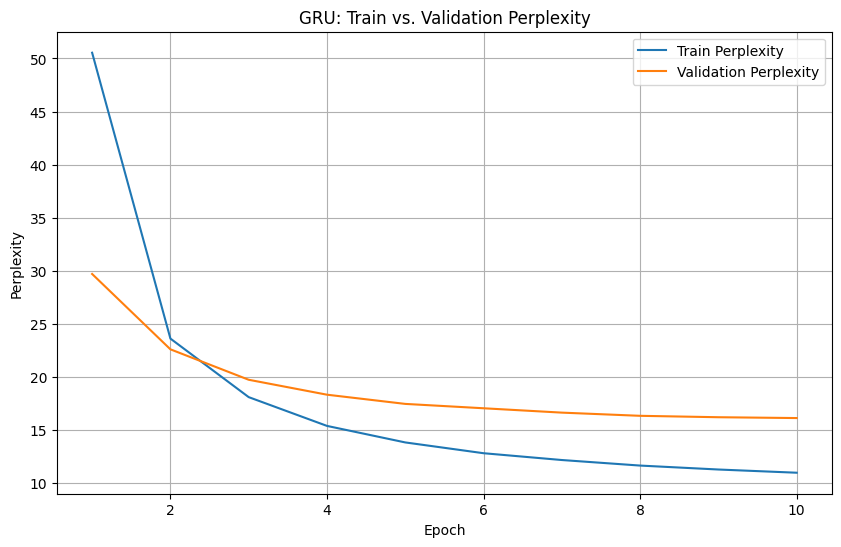

In [23]:
# Consolidated plotting functions will be generated later.

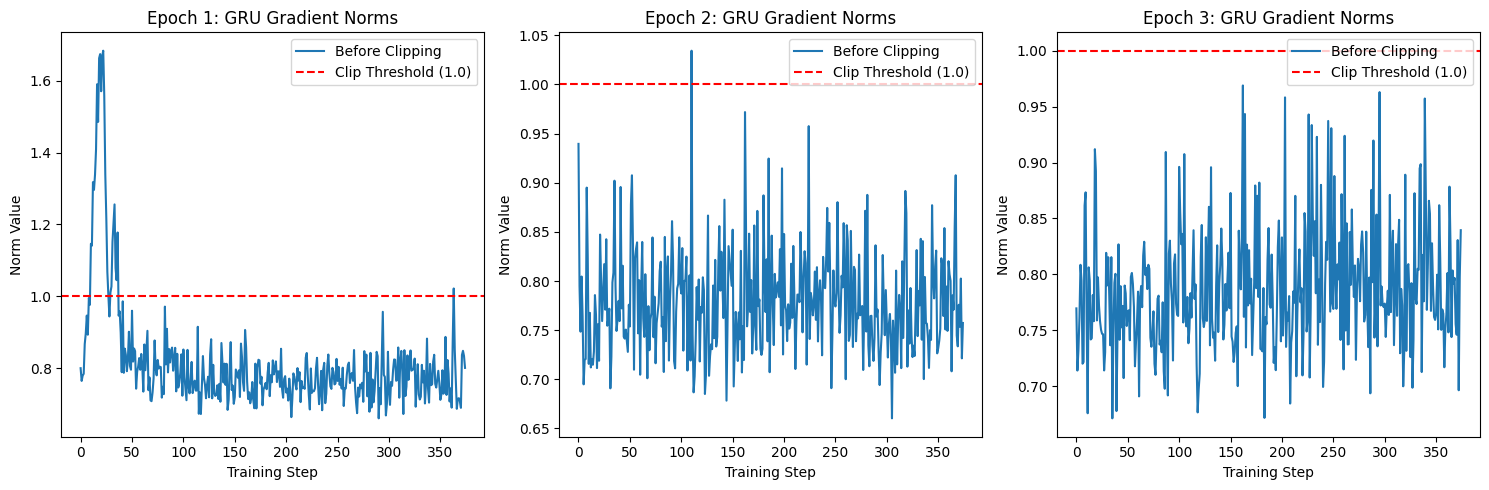

In [24]:
# Consolidated plotting functions will be generated later.

## SECTION 6 - Seq2Seq Model

In [ ]:
# Seq2Seq Encoder
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.hid_dim = hid_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid_dim, n_layers, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: [batch_size, src_len]

        embedded = self.dropout(self.embedding(src))
        # embedded: [batch_size, src_len, emb_dim]

        outputs, hidden = self.rnn(embedded)
        # outputs: [batch_size, src_len, hid_dim * num_directions] (if bidirectional)
        # hidden: [n_layers * num_directions, batch_size, hid_dim]

        return outputs, hidden

# Seq2Seq Decoder
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim + hid_dim, hid_dim, n_layers, dropout=dropout, batch_first=True)
        self.fc_out = nn.Linear(emb_dim + hid_dim + hid_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        # input: [batch_size]
        # hidden: [n_layers, batch_size, hid_dim]
        # encoder_outputs: [batch_size, src_len, hid_dim]

        input = input.unsqueeze(1) # input: [batch_size, 1]

        embedded = self.dropout(self.embedding(input))
        # embedded: [batch_size, 1, emb_dim]

        # Simple Attention: calculate attention weights using dot product
        # Attention energy (alignment scores)
        # hidden[-1,:,:] is the top layer hidden state [batch_size, hid_dim]
        energy = torch.bmm(encoder_outputs, hidden[-1,:,:].unsqueeze(2)).squeeze(2)
        # energy: [batch_size, src_len]

        attention = torch.softmax(energy, dim=1)
        # attention: [batch_size, src_len]

        # Weighted sum of encoder outputs
        context = torch.bmm(attention.unsqueeze(1), encoder_outputs).squeeze(1)
        # context: [batch_size, hid_dim]

        rnn_input = torch.cat((embedded.squeeze(1), context), dim=1).unsqueeze(1)
        # rnn_input: [batch_size, 1, emb_dim + hid_dim]

        output, hidden = self.rnn(rnn_input, hidden)
        # output: [batch_size, 1, hid_dim]
        # hidden: [n_layers, batch_size, hid_dim]

        # Concatenate output, context, and embedded for final prediction
        prediction = self.fc_out(torch.cat((output.squeeze(1), context, embedded.squeeze(1)), dim=1))
        # prediction: [batch_size, output_dim]

        return prediction, hidden


# Seq2Seq Model with Attention
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

        # Ensure the hidden dimensions of encoder and decoder match
        assert encoder.hid_dim == decoder.hid_dim, \
            "Hidden dimensions of encoder and decoder must be equal!"
        assert encoder.n_layers == decoder.n_layers, \
            "Encoder and decoder must have equal number of layers!"

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src: [batch_size, src_len] (French)
        # trg: [batch_size, trg_len] (English)
        # teacher_forcing_ratio is probability to use teacher forcing
        # e.g. if 0.75 we use ground-truth inputs 75% of the time

        batch_size = trg.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.output_dim

        # Tensor to store decoder outputs
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)

        # encoder_outputs is all hidden states of the input sequence
        # hidden is the final hidden state of the encoder
        encoder_outputs, hidden = self.encoder(src)

        # First input to the decoder is the <bos> token
        input = trg[:, 0]

        for t in range(1, trg_len):
            # Insert input token embedding, previous hidden state and all encoder outputs
            # then receive output and new hidden state
            output, hidden = self.decoder(input, hidden, encoder_outputs)

            # Store prediction in outputs tensor
            outputs[:, t, :] = output

            # Decide if we are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio

            # Get the highest predicted token from our predictions
            top1 = output.argmax(1)

            # If teacher forcing, use actual next token as next input
            # If not, use predicted token
            input = trg[:, t] if teacher_force else top1

        return outputs

# Seq2Seq Specific Parameters
ENC_INPUT_DIM = len(french_vocab)
DEC_OUTPUT_DIM_SEQ2SEQ = len(english_vocab) # Renamed to avoid conflict with LM_OUTPUT_DIM
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM_SEQ2SEQ = 512 # Increased hidden dimension for Seq2Seq
N_LAYERS_SEQ2SEQ = 1
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(ENC_INPUT_DIM, ENC_EMB_DIM, HID_DIM_SEQ2SEQ, N_LAYERS_SEQ2SEQ, ENC_DROPOUT)
dec = Decoder(DEC_OUTPUT_DIM_SEQ2SEQ, DEC_EMB_DIM, HID_DIM_SEQ2SEQ, N_LAYERS_SEQ2SEQ, DEC_DROPOUT)

seq2seq_model = Seq2Seq(enc, dec, device).to(device)
seq2seq_optimizer = optim.Adam(seq2seq_model.parameters(), lr=0.001)
criterion_seq2seq = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

print("\nSeq2Seq Model Summary:")
print(seq2seq_model)
print(f"The Seq2Seq model has {sum(p.numel() for p in seq2seq_model.parameters() if p.requires_grad):,} trainable parameters")

def init_weights(m):
    for name, param in m.named_parameters():
        if 'weight' in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        else:
            nn.init.constant_(param.data, 0)

seq2seq_model.apply(init_weights)

def train_seq2seq_model(model, iterator, optimizer, criterion, clip_val, teacher_forcing_ratio):
    model.train()
    epoch_loss = 0
    all_grad_norms = []

    for i, batch in enumerate(iterator):
        src = batch['french'].to(device)
        trg = batch['english'].to(device)

        optimizer.zero_grad()

        output = model(src, trg, teacher_forcing_ratio)
        # trg: [batch_size, trg_len]
        # output: [batch_size, trg_len, output_dim]

        # target tokens are trg[:, 1:] because the first token is <bos>
        # output predictions are output[:, 1:] to match targets
        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()

        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), clip_val)
        all_grad_norms.append(grad_norm.item())

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator), all_grad_norms

def evaluate_seq2seq_model(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for i, batch in enumerate(iterator):
            src = batch['french'].to(device)
            trg = batch['english'].to(device)

            output = model(src, trg, 0) # Turn off teacher forcing for evaluation

            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)

            loss = criterion(output, trg)

            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

# Training loop for Seq2Seq
N_EPOCHS_SEQ2SEQ = 10
CLIP_SEQ2SEQ = 1.0
TEACHER_FORCING_RATIO = 0.5

seq2seq_train_losses = []
seq2seq_val_losses = []
seq2seq_train_perplexities = []
seq2seq_val_perplexities = []

seq2seq_grad_norms_per_epoch = []

print("\nTraining Seq2Seq Model...")
for epoch in range(N_EPOCHS_SEQ2SEQ):
    train_loss, grad_norms = train_seq2seq_model(seq2seq_model, train_loader, seq2seq_optimizer, criterion_seq2seq, CLIP_SEQ2SEQ, TEACHER_FORCING_RATIO)
    val_loss = evaluate_seq2seq_model(seq2seq_model, val_loader, criterion_seq2seq)

    seq2seq_train_losses.append(train_loss)
    seq2seq_val_losses.append(val_loss)

    seq2seq_train_perplexities.append(np.exp(train_loss))
    seq2seq_val_perplexities.append(np.exp(val_loss))

    # Only store grad norms for first 3 epochs to avoid excessive memory usage for very long trainings
    if epoch < 3:
        seq2seq_grad_norms_per_epoch.append({'epoch': epoch+1, 'grad_norms': grad_norms})

    print(f'Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Train PPL: {np.exp(train_loss):.2f} | Val Loss: {val_loss:.3f} | Val PPL: {np.exp(val_loss):.2f}')

print("\nSeq2Seq Model Training Complete.")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1364: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  super().__init__("GRU", *args, **kwargs)



Seq2Seq Model Summary:
Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(2978, 256)
    (rnn): GRU(256, 512, batch_first=True, dropout=0.5)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(1864, 256)
    (rnn): GRU(768, 512, batch_first=True, dropout=0.5)
    (fc_out): Linear(in_features=1280, out_features=1864, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)
The Seq2Seq model has 6,779,208 trainable parameters

Training Seq2Seq Model...
Epoch: 01 | Train Loss: 4.064 | Train PPL: 58.23 | Val Loss: 3.694 | Val PPL: 40.22
Epoch: 02 | Train Loss: 3.082 | Train PPL: 21.80 | Val Loss: 2.972 | Val PPL: 19.53


In [ ]:
# Consolidated plotting functions will be generated later.

In [ ]:
# Consolidated plotting functions will be generated later.